Measured d(xy)/dt = 0.4297761767788776
Measured shear rate = 0.009117997430637839
Target shear rate = 0.001


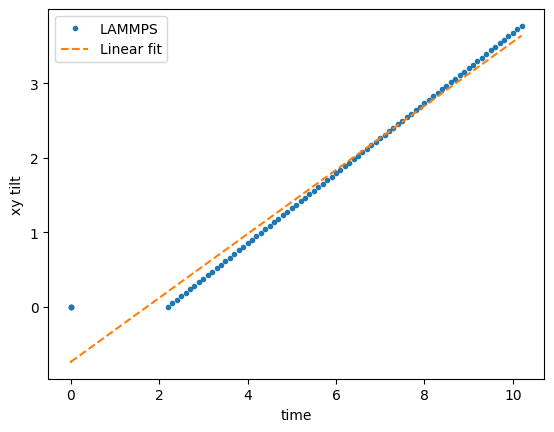

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- user inputs ---
logfile = "log.lammps"
gdot = 1e-3
Ly = 47.1349306740058   # from your print output

# --- parse thermo data ---
time = []
xy = []

with open(logfile, "r") as f:
    for line in f:
        if line.strip().startswith("#"):
            continue
        tokens = line.split()
        if len(tokens) < 5:
            continue
        try:
            step = int(tokens[0])
            t = float(tokens[1])
            xyval = float(tokens[3])  # adjust index if needed
            time.append(t)
            xy.append(xyval)
        except:
            pass

time = np.array(time)
xy = np.array(xy)

# --- linear fit ---
coeffs = np.polyfit(time, xy, 1)
dxy_dt = coeffs[0]
gdot_meas = dxy_dt / Ly

print("Measured d(xy)/dt =", dxy_dt)
print("Measured shear rate =", gdot_meas)
print("Target shear rate =", gdot)

# --- plot ---
plt.plot(time, xy, "o", ms=3, label="LAMMPS")
plt.plot(time, np.polyval(coeffs, time), "--", label="Linear fit")
plt.xlabel("time")
plt.ylabel("xy tilt")
plt.legend()
plt.show()